In [3]:
# Import pandas libraries for data pre-processing and data manipulation
import pandas as pd

# Import sklearn libraries for the ML algorithms
from sklearn.preprocessing import LabelEncoder
# Importing descision tree algorithm
from sklearn.tree import DecisionTreeClassifier
# For evaluating the accuracy
from sklearn.metrics import accuracy_score, classification_report

# (optional) Importing Naive-Bayes classifier algorithm
from sklearn.naive_bayes import CategoricalNB

# Import Graphviz
import graphviz

In [2]:
# Install graphviz Python package
!pip install graphviz

# Install pydotplus
!pip install pydotplus

  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24575 sha256=c62fa399e7d9300669c13bdd1a2306fc02490d1aa681e666052c3a59e48cece3
  Stored in directory: c:\users\ozget\appdata\local\pip\cache\wheels\89\e5\de\6966007cf223872eedfbebbe0e074534e72e9128c8fd4b55eb
Successfully built pydotplus


NOTE:
The pandas library alone can handle data loading and manipulation, but it doesn't include machine learning algorithms - that's where sklearn comes in. Sklearn provides the implementations of these algorithms that you'll train on your preprocessed data.

In [4]:
# Load data (using pandas)
data = pd.read_csv('play_tennis.csv')

In [6]:
# Printing the overview of the raw dataset
data.head()

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


Our target (what we are trying to predict) variable is 'play' so we dropping that since 
it is not a variable used for prediction.

In supervised machine learning:
X (features) contains the input variables we use to make predictions
y (target) contains the output variable we want to predict

Here's why we need to separate them:
When we call data.drop('play', axis=1), we're creating a dataset X that has all columns EXCEPT 'play'
Then with y = data['play'], we're isolating just the 'play' column as our target

This separation is necessary because the machine learning algorithm learns the relationship between the features (outlook, temperature, humidity, wind) and the target (play). The model takes X as input and tries to predict y.

If we left 'play' in our features, we'd essentially be telling the model "use whether someone played tennis to predict whether someone played tennis" - which would give perfect but meaningless predictions since we're leaking the answer.

In [7]:
# Preprocessing
# Drop the play variable. The dataset X has all columns EXCEPT 'play'. 
X = data.drop('play', axis=1)  # Features

# Contain/Isolate the output variable in y. 
y = data['play']               # Target

In [8]:
# Convert categorical variables to numerical (converts text data into numerical)
# Machine learning algorithms like Decision Trees in scikit-learn require numerical input.

# Option 1: Label Encoding
# Creates a new instance of sklearn's LabelEncoder (a tool for converting text labels to numbers)
label_encoder = LabelEncoder()

# For each column in your features:
# The encoder learns all unique values in that column (the fit part)
# Transforms each text value to a unique number (the transform part)
# For example, in the "outlook" column, "sunny" might become 0, "overcast" might become 1, and "rain" might become 2
for col in X.columns:
    X[col] = label_encoder.fit_transform(X[col])

# Convert your target variable from text to numerical
y = label_encoder.fit_transform(y)

Now that each column has been assigned a unique integer, we can move on to training the model.

In [9]:
# "entropy" refers to the mathematical measure used to decide where to split the decision tree during training.
# Entropy is calculated as the sum of the probability of each class times the log probability of that class:
# Entropy = -Σ [p(i) * log₂(p(i))] where p(i) is the probability of class i.

# Train model
model = DecisionTreeClassifier(criterion='entropy')

# fit() is where your model transforms from an empty framework to a trained predictor that has learned patterns from 
# your data. After this step, your model is ready to make predictions with the .predict() method.
model.fit(X, y)

DecisionTreeClassifier(criterion='entropy')

Interpretation:
If all examples belong to the same class (perfectly pure node), entropy = 0
If examples are evenly split between classes (maximum impurity), entropy is at its maximum

For binary classification like your tennis example:
When all examples are "yes" or all are "no": entropy = 0
When 50% are "yes" and 50% are "no": entropy = 1

Decision Process: The algorithm calculates entropy before and after each potential split, selecting the feature that produces the greatest reduction in entropy (highest information gain).

The alternative criterion is "gini" impurity, which works similarly but uses a different mathematical formula. Both work well, but entropy tends to create more balanced trees and is often preferred for educational purposes because it connects to information theory concepts.

In [10]:
# Make predictions and evaluate
predictions = model.predict(X)
print("Accuracy:", accuracy_score(y, predictions))
print(classification_report(y, predictions))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



In [13]:
#Visualize tree (optional, requires graphviz)
export_graphviz(model, out_file='tree.dot', feature_names=X.columns)

In [15]:
# To save the image in current working directory
import os
# Export tree to DOT file
export_graphviz(model, out_file='tree.dot', 
                feature_names=X.columns,
                class_names=['No', 'Yes'],
                filled=True)

# Use the full path to dot.exe to convert the file
os.system(r'"C:\Program Files\Graphviz\bin\dot.exe" -Tpng tree.dot -o decision_tree.png')

# Check if the file was created
print(os.path.exists('decision_tree.png'))

True


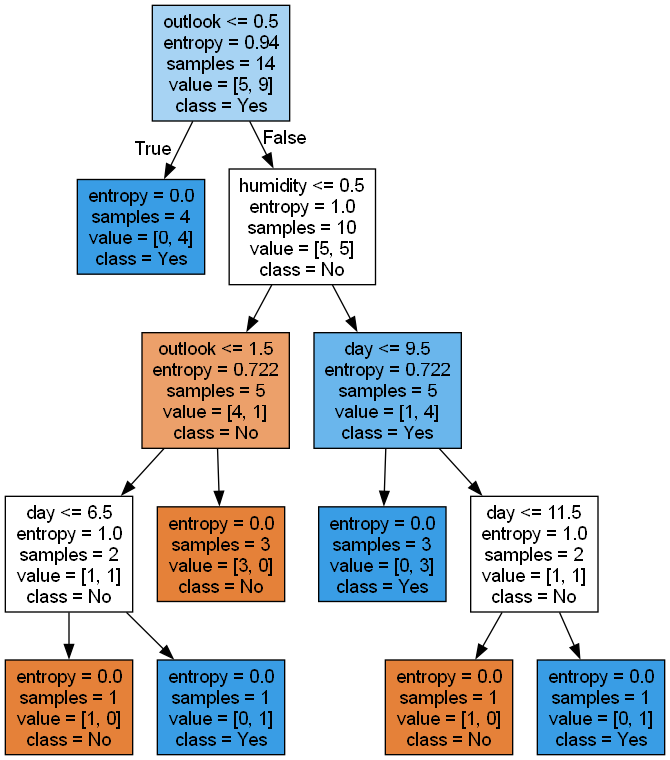

In [16]:
# To display image directly in Notebook
from IPython.display import Image
Image('decision_tree.png')

### END